In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import matplotlib.pyplot as plt


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    for cand in candidates:
        if (cand / "scripts" / "preprocess_data.py").exists() and (cand / "configs" / "train.yaml").exists():
            return cand
    fallback = Path("/home/raj/Documents/CODING/Hackathon/ANRF_AISEHack_Final_2/Ronit_new")
    if fallback.exists():
        return fallback
    raise FileNotFoundError("Could not locate project root for Ronit_new")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.preprocess_data import normalize_array

RAW_ROOT = Path("/home/raj/Documents/CODING/Hackathon/ANRF_AISEHack_Final_2/data/raw")
STATS_PATH = PROJECT_ROOT / "artifacts" / "preprocessing" / "normalization_stats.json"
OUT_DIR = PROJECT_ROOT / "eda" / "artifacts" / "plots" / "post_preprocess_feature_diagnostics"
OUT_DIR.mkdir(parents=True, exist_ok=True)

with STATS_PATH.open("r", encoding="utf-8") as f:
    stats = json.load(f)

feature_order = stats["feature_order"]
months = stats.get("fit_months", ["APRIL_16", "JULY_16", "OCT_16", "DEC_16"])

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw root: {RAW_ROOT}")
print(f"Stats path: {STATS_PATH}")
print(f"Output dir: {OUT_DIR}")
print(f"Features ({len(feature_order)}): {feature_order}")
print(f"Months: {months}")

Project root: /home/raj/Documents/CODING/Hackathon/ANRF_AISEHack_Final_2/Ronit_new
Raw root: /home/raj/Documents/CODING/Hackathon/ANRF_AISEHack_Final_2/data/raw
Stats path: /home/raj/Documents/CODING/Hackathon/ANRF_AISEHack_Final_2/Ronit_new/artifacts/preprocessing/normalization_stats.json
Output dir: /home/raj/Documents/CODING/Hackathon/ANRF_AISEHack_Final_2/Ronit_new/eda/artifacts/plots/post_preprocess_feature_diagnostics
Features (16): ['cpm25', 'q2', 't2', 'u10', 'v10', 'swdown', 'pblh', 'psfc', 'rain', 'PM25', 'NH3', 'SO2', 'NOx', 'NMVOC_e', 'NMVOC_finn', 'bio']
Months: ['APRIL_16', 'JULY_16', 'OCT_16', 'DEC_16']


In [2]:
saved_paths = []

for feature in feature_order:
    feature_payload = stats["features"][feature]

    raw_chunks = []
    norm_chunks = []
    for month in months:
        arr_path = RAW_ROOT / month / f"{feature}.npy"
        arr = np.load(arr_path, mmap_mode="r")
        arr_np = np.asarray(arr, dtype=np.float32)

        raw_chunks.append(arr_np.reshape(-1))
        norm_arr = normalize_array(arr_np, feature_payload)
        norm_chunks.append(norm_arr.reshape(-1))

    raw_values = np.concatenate(raw_chunks, axis=0)
    norm_values = np.concatenate(norm_chunks, axis=0)

    max_points = 250000
    if raw_values.size > max_points:
        rng = np.random.default_rng(42)
        idx = rng.choice(raw_values.size, size=max_points, replace=False)
        raw_plot = raw_values[idx]
        norm_plot = norm_values[idx]
    else:
        raw_plot = raw_values
        norm_plot = norm_values

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    axes[0].hist(raw_plot, bins=120, color="#1f77b4", alpha=0.85, log=True)
    axes[0].set_title(f"{feature} - Raw distribution")
    axes[0].set_xlabel("Value")
    axes[0].set_ylabel("Count (log scale)")

    axes[1].hist(norm_plot, bins=120, color="#2ca02c", alpha=0.85, log=True)
    axes[1].set_title(f"{feature} - After preprocessing")
    axes[1].set_xlabel("Normalized value")
    axes[1].set_ylabel("Count (log scale)")

    fig.suptitle(
        f"{feature} | transform={feature_payload['transform']} | scaler={feature_payload['scaler']}",
        fontsize=12,
    )
    fig.tight_layout()

    out_path = OUT_DIR / f"{feature}_post_preprocess_distribution.png"
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    saved_paths.append(out_path)

print(f"Saved {len(saved_paths)} images to: {OUT_DIR}")
saved_paths[:5]

Saved 16 images to: /home/raj/Documents/CODING/Hackathon/ANRF_AISEHack_Final_2/Ronit_new/eda/artifacts/plots/post_preprocess_feature_diagnostics


[PosixPath('/home/raj/Documents/CODING/Hackathon/ANRF_AISEHack_Final_2/Ronit_new/eda/artifacts/plots/post_preprocess_feature_diagnostics/cpm25_post_preprocess_distribution.png'),
 PosixPath('/home/raj/Documents/CODING/Hackathon/ANRF_AISEHack_Final_2/Ronit_new/eda/artifacts/plots/post_preprocess_feature_diagnostics/q2_post_preprocess_distribution.png'),
 PosixPath('/home/raj/Documents/CODING/Hackathon/ANRF_AISEHack_Final_2/Ronit_new/eda/artifacts/plots/post_preprocess_feature_diagnostics/t2_post_preprocess_distribution.png'),
 PosixPath('/home/raj/Documents/CODING/Hackathon/ANRF_AISEHack_Final_2/Ronit_new/eda/artifacts/plots/post_preprocess_feature_diagnostics/u10_post_preprocess_distribution.png'),
 PosixPath('/home/raj/Documents/CODING/Hackathon/ANRF_AISEHack_Final_2/Ronit_new/eda/artifacts/plots/post_preprocess_feature_diagnostics/v10_post_preprocess_distribution.png')]

Displaying 16 post-preprocessing distribution images
NH3_post_preprocess_distribution.png


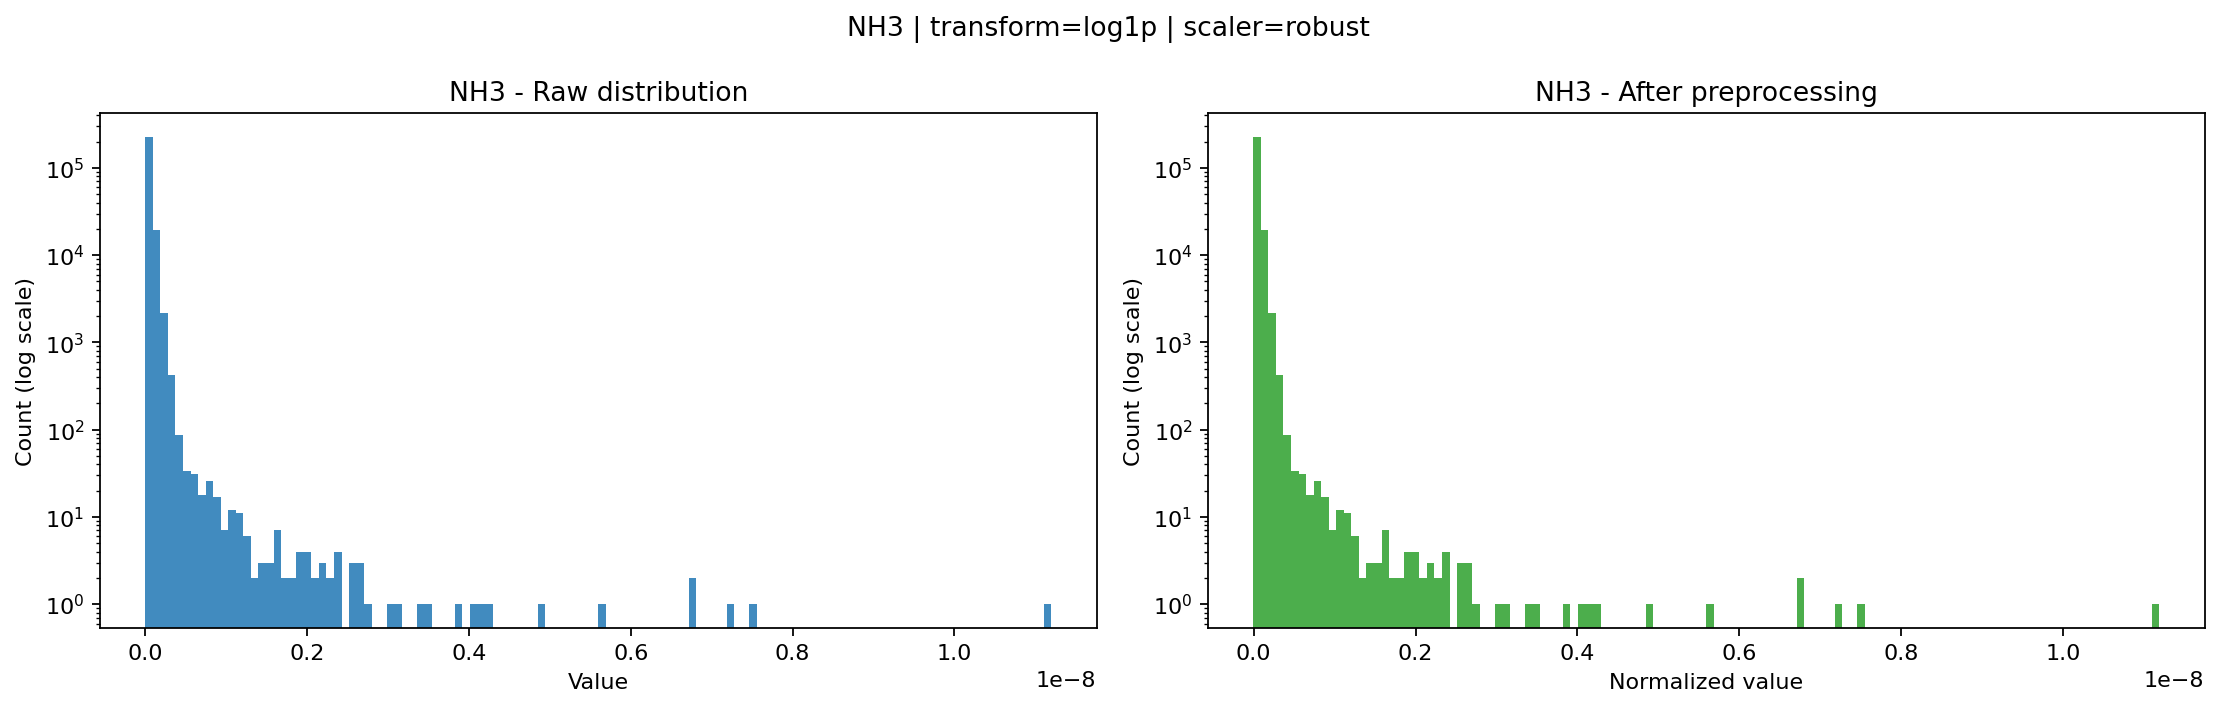

NMVOC_e_post_preprocess_distribution.png


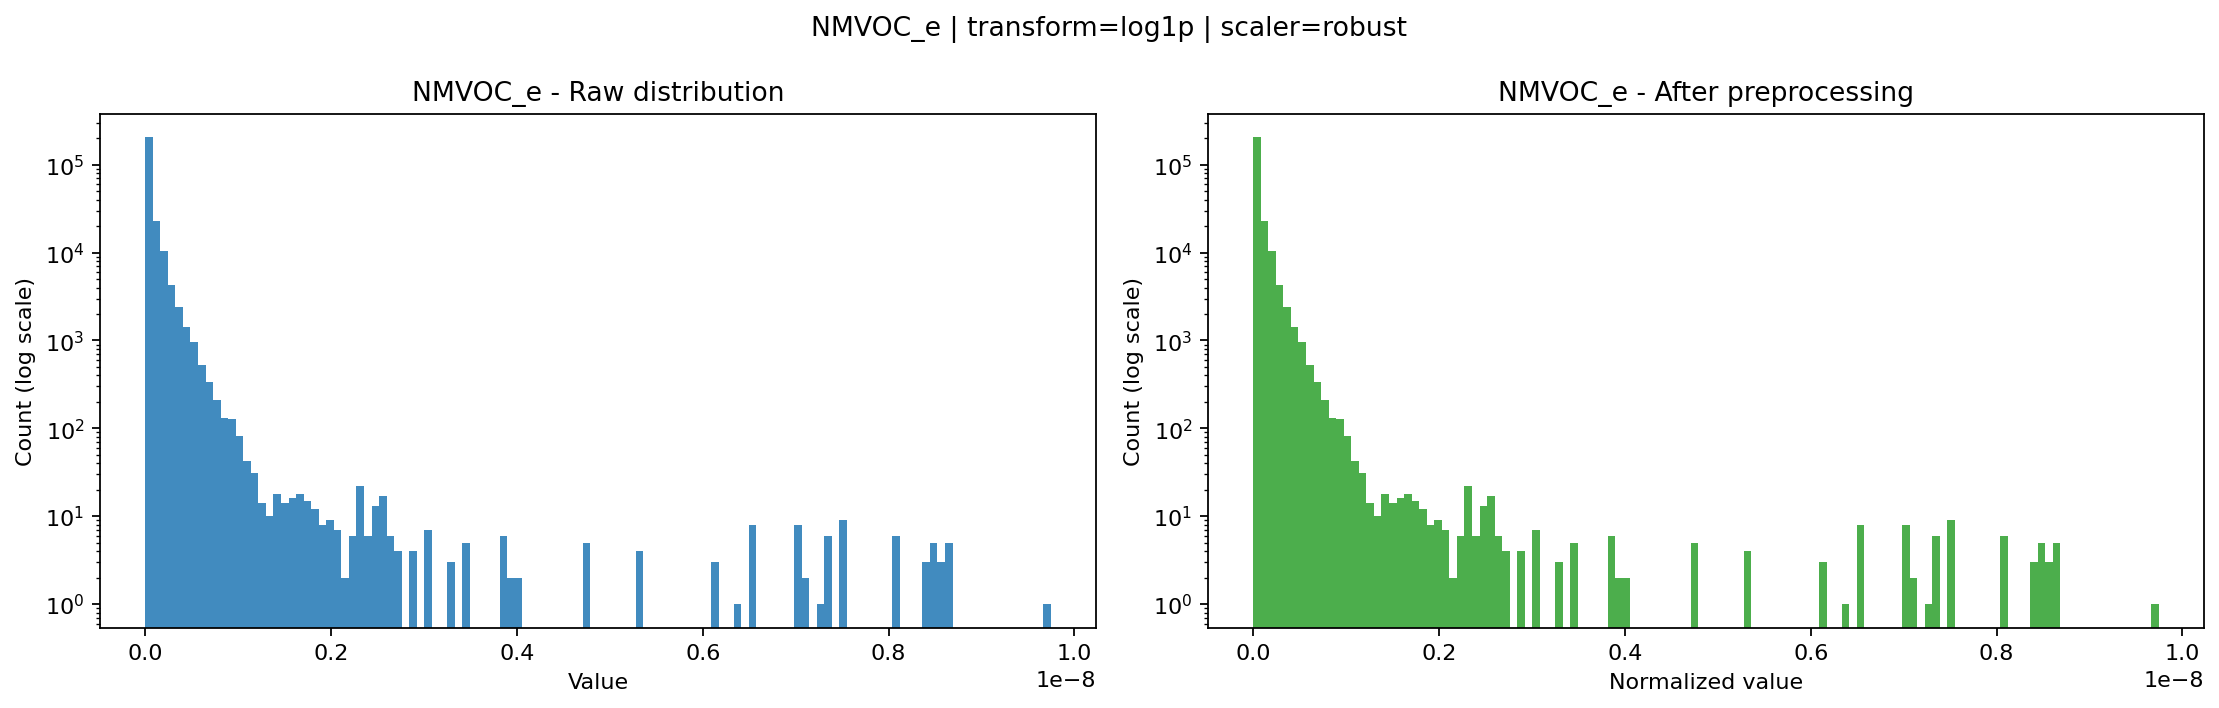

NMVOC_finn_post_preprocess_distribution.png


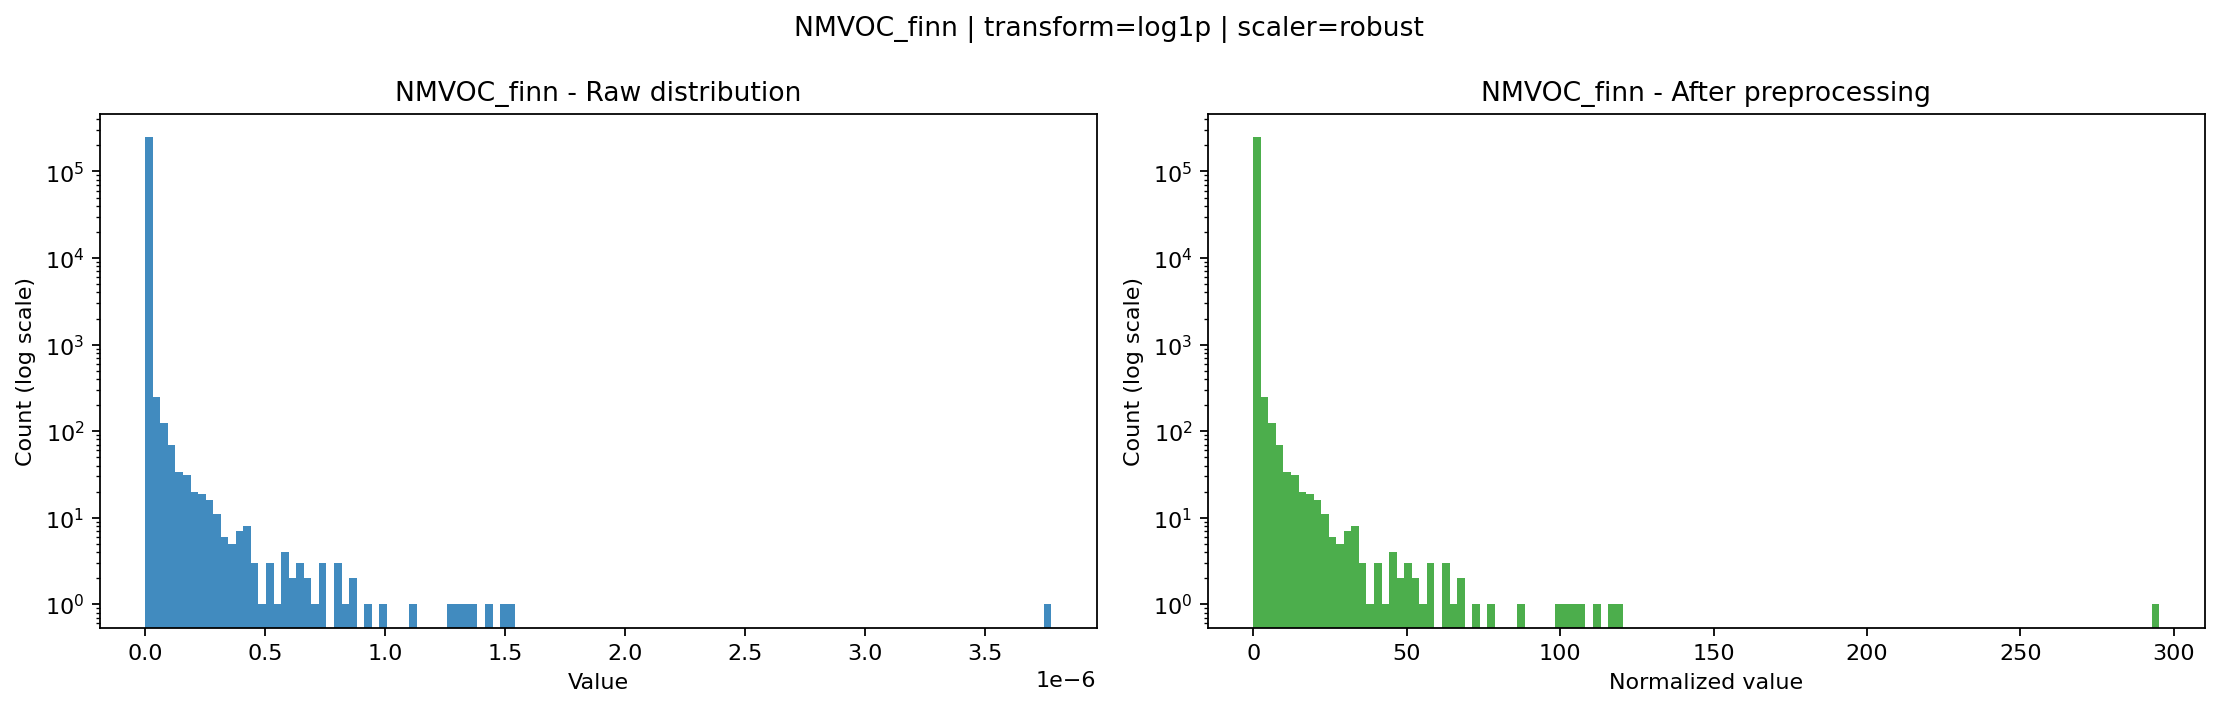

NOx_post_preprocess_distribution.png


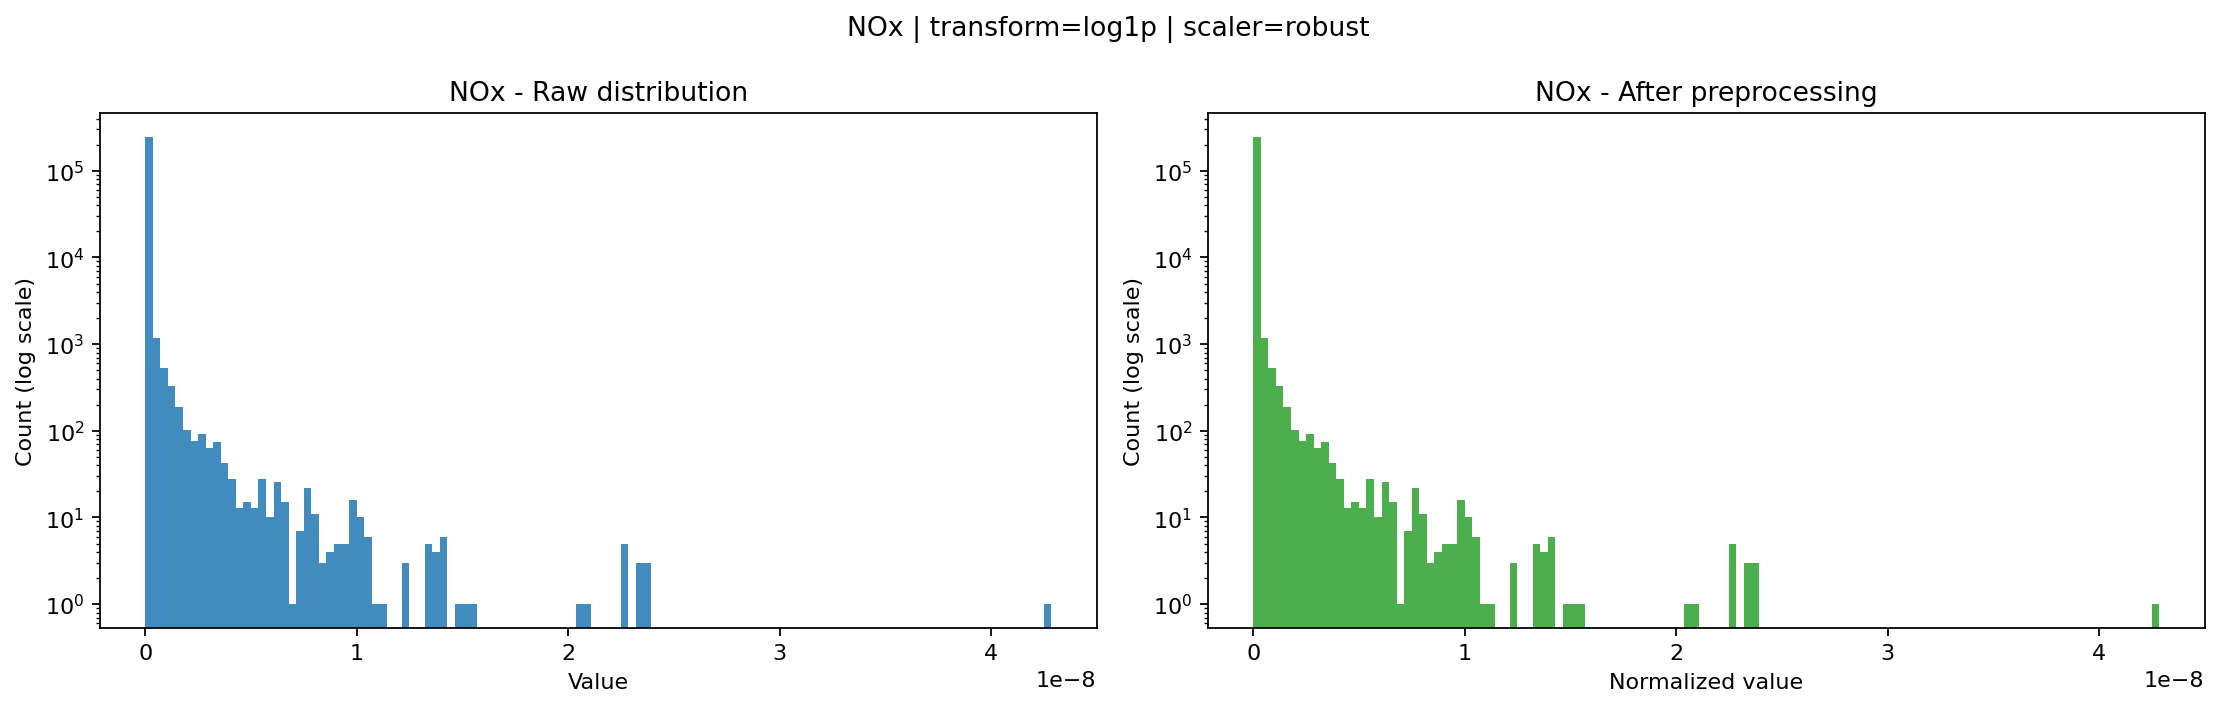

PM25_post_preprocess_distribution.png


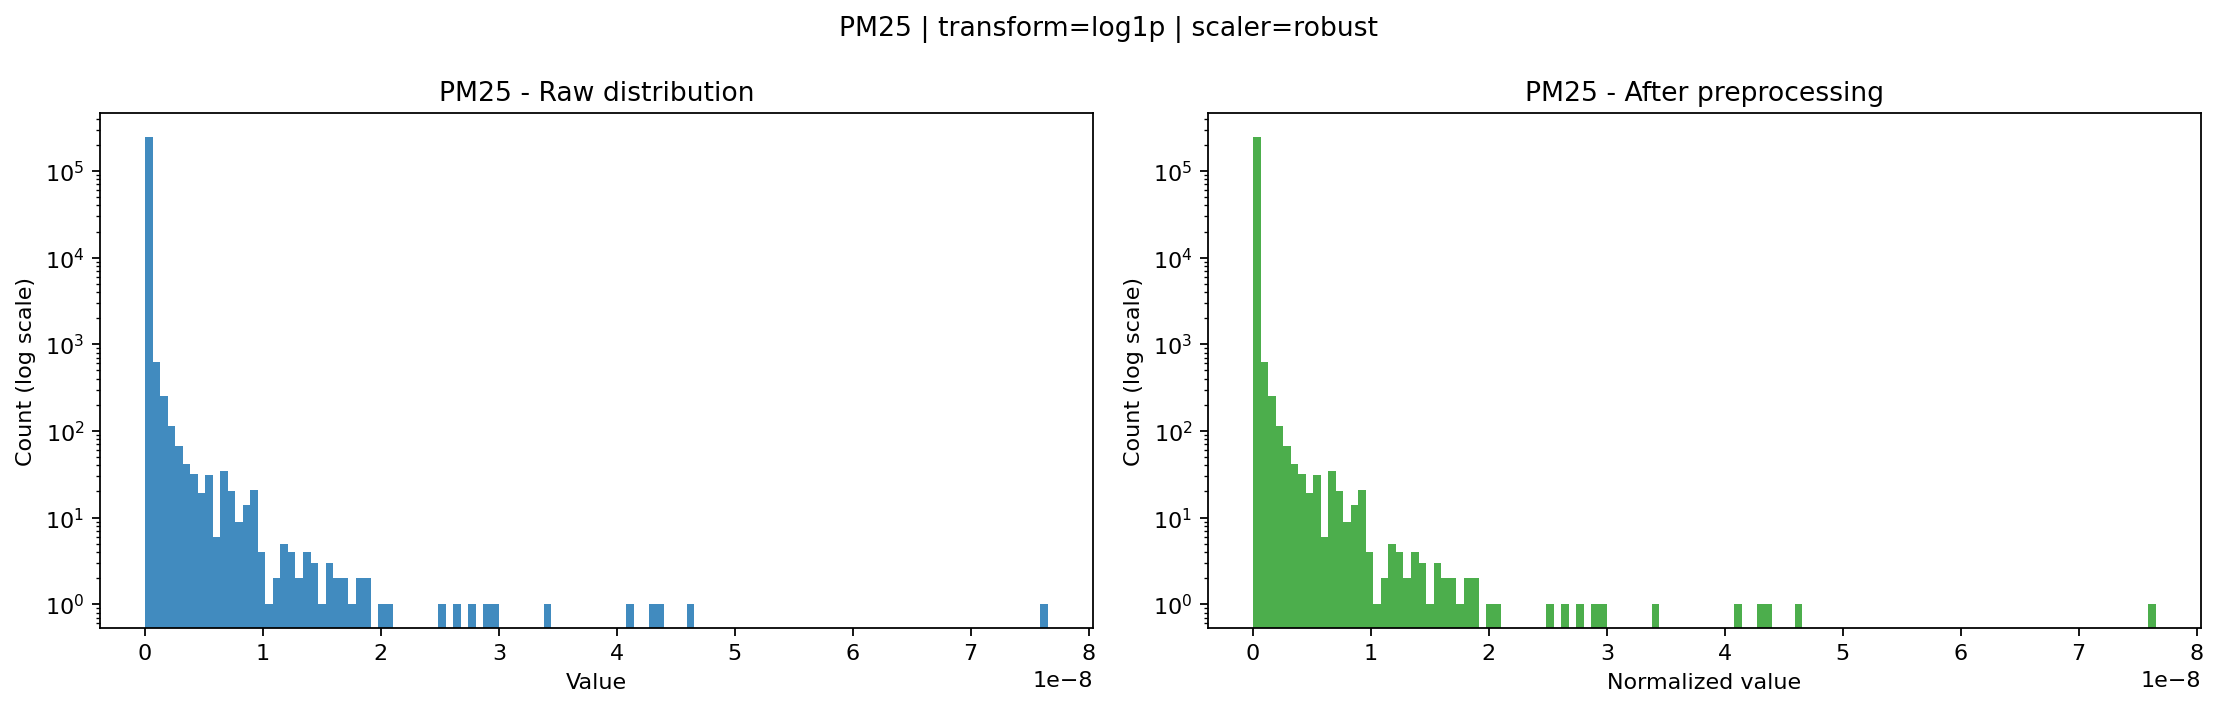

SO2_post_preprocess_distribution.png


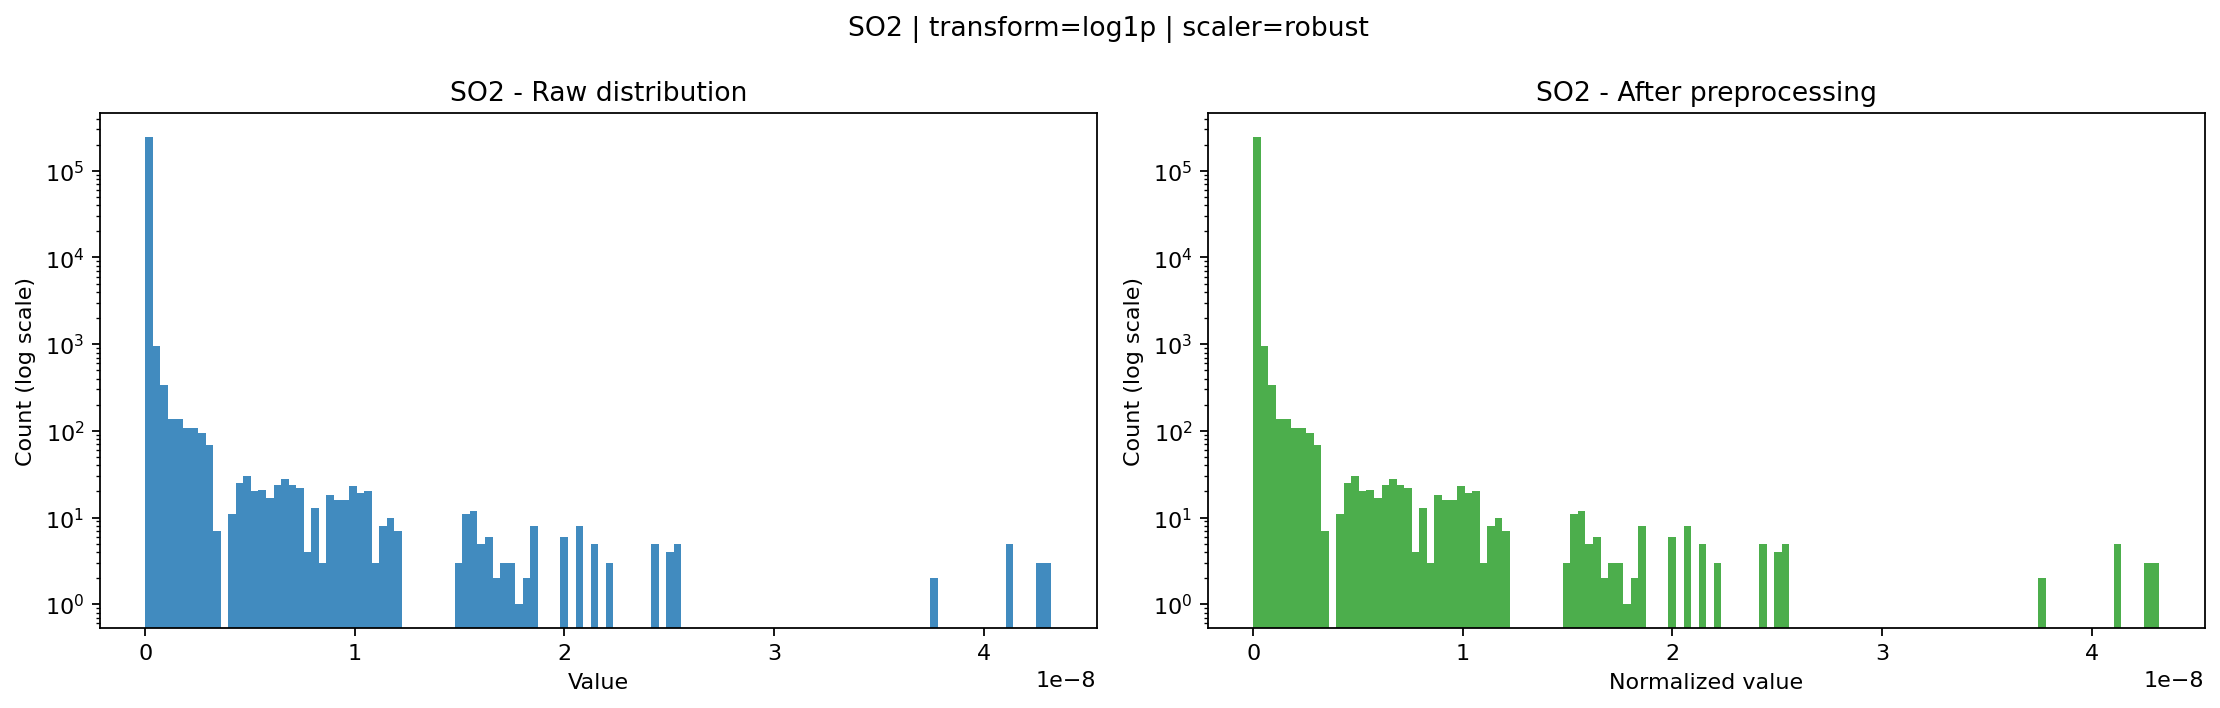

bio_post_preprocess_distribution.png


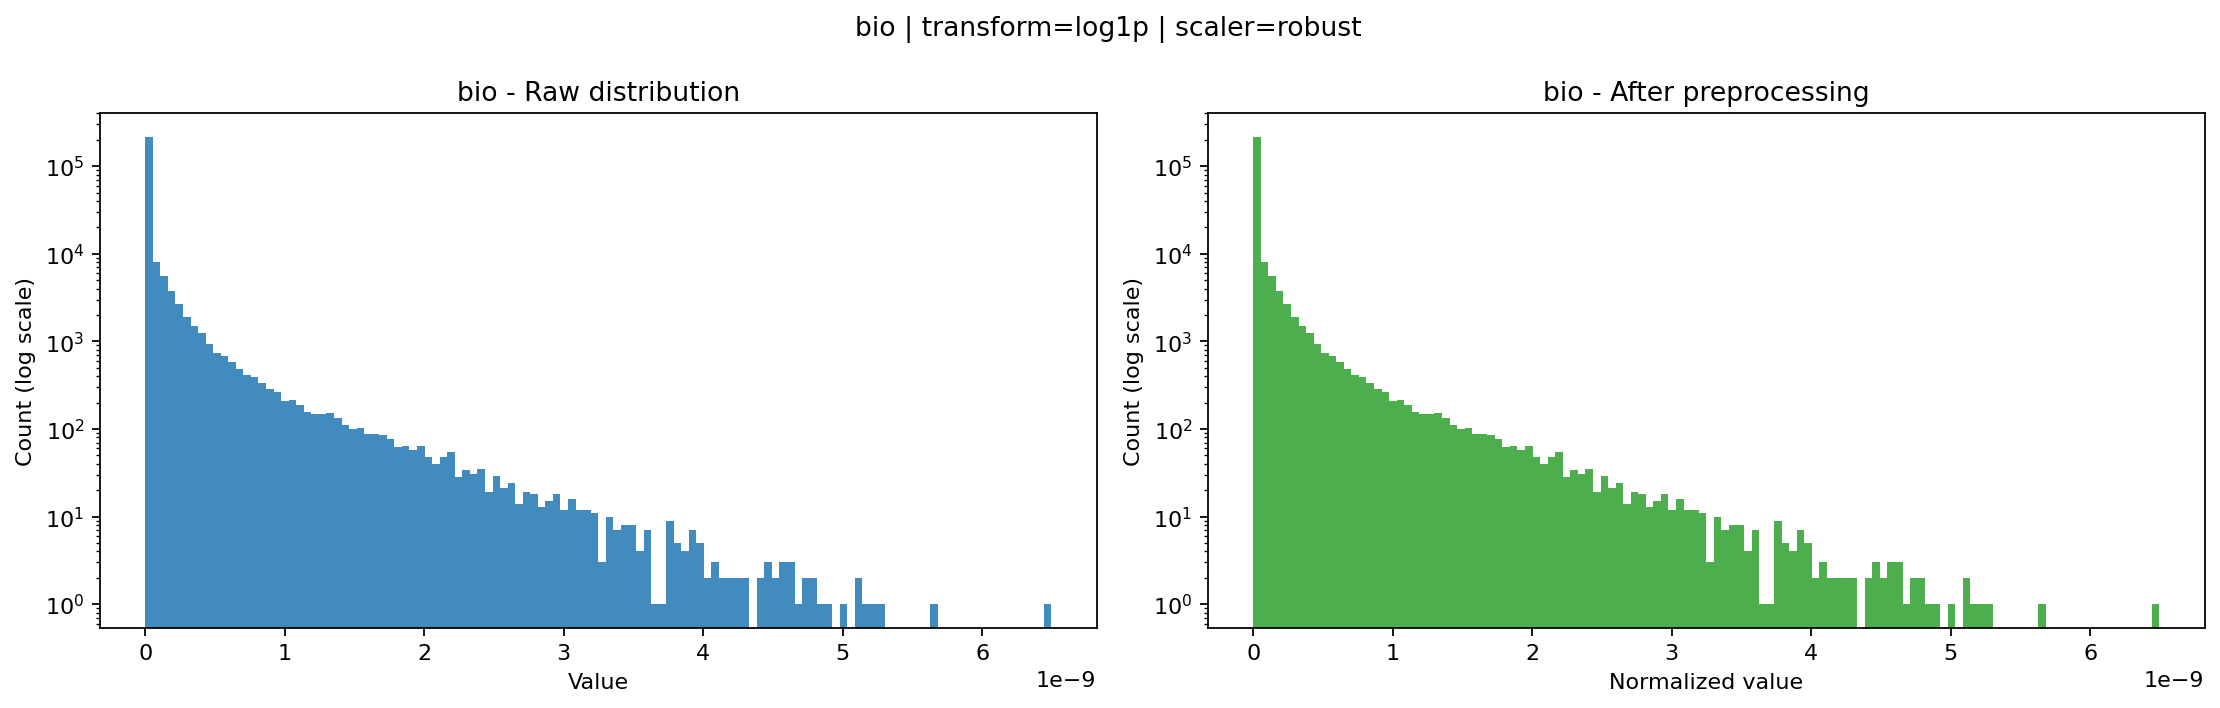

cpm25_post_preprocess_distribution.png


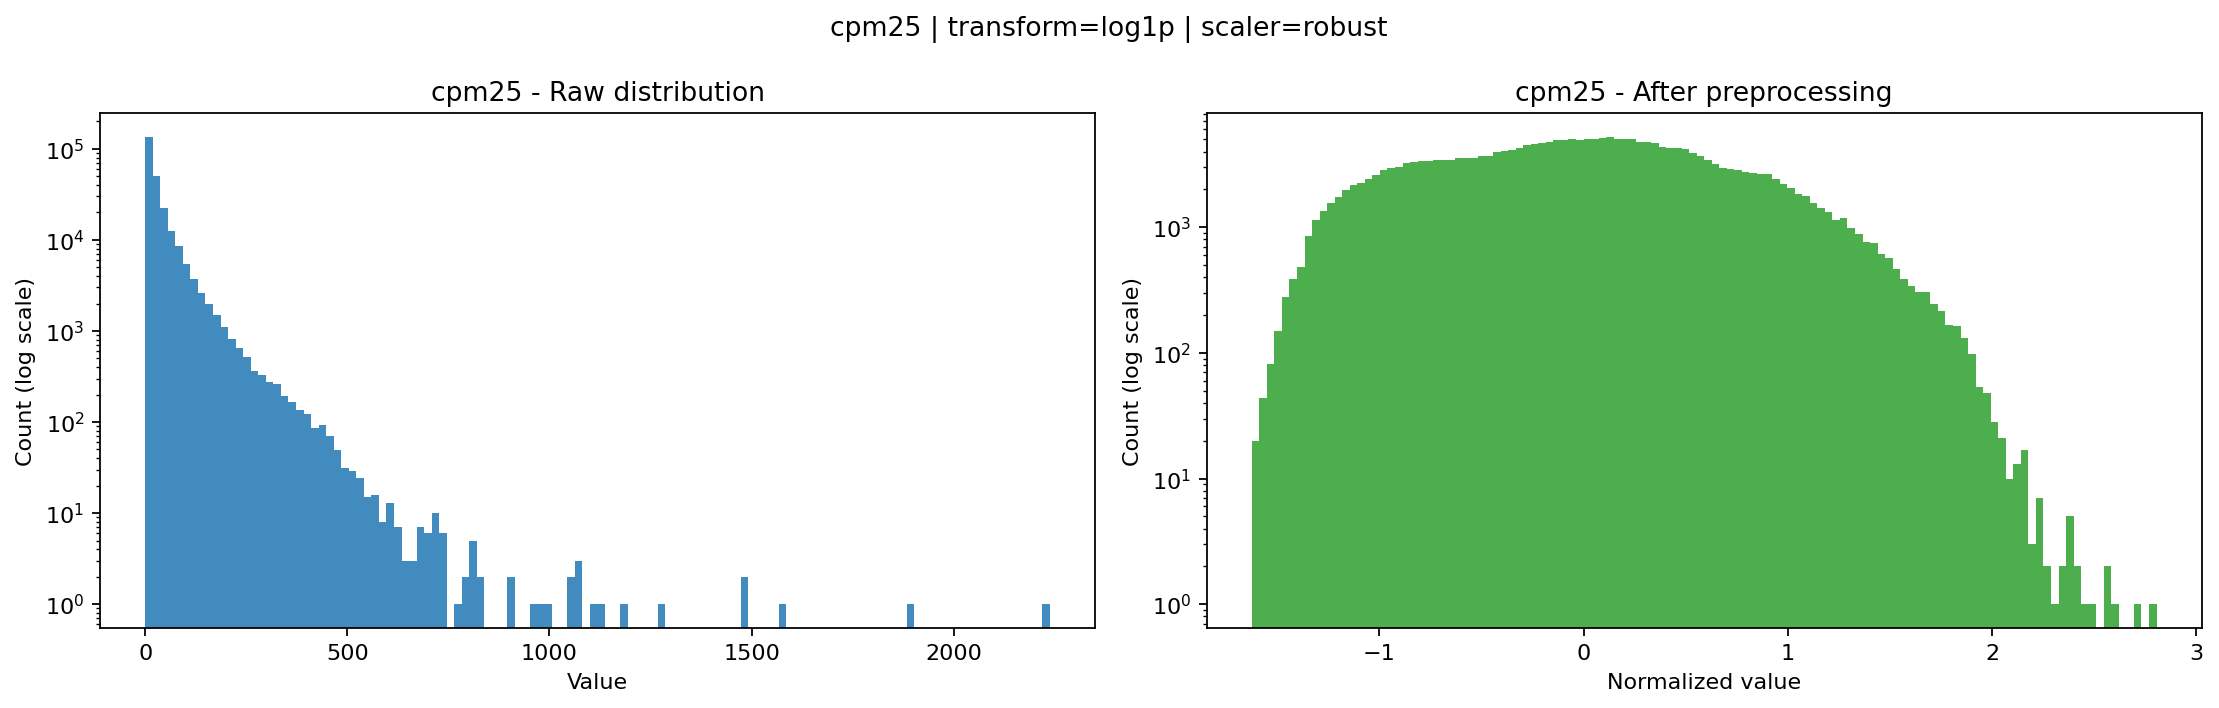

pblh_post_preprocess_distribution.png


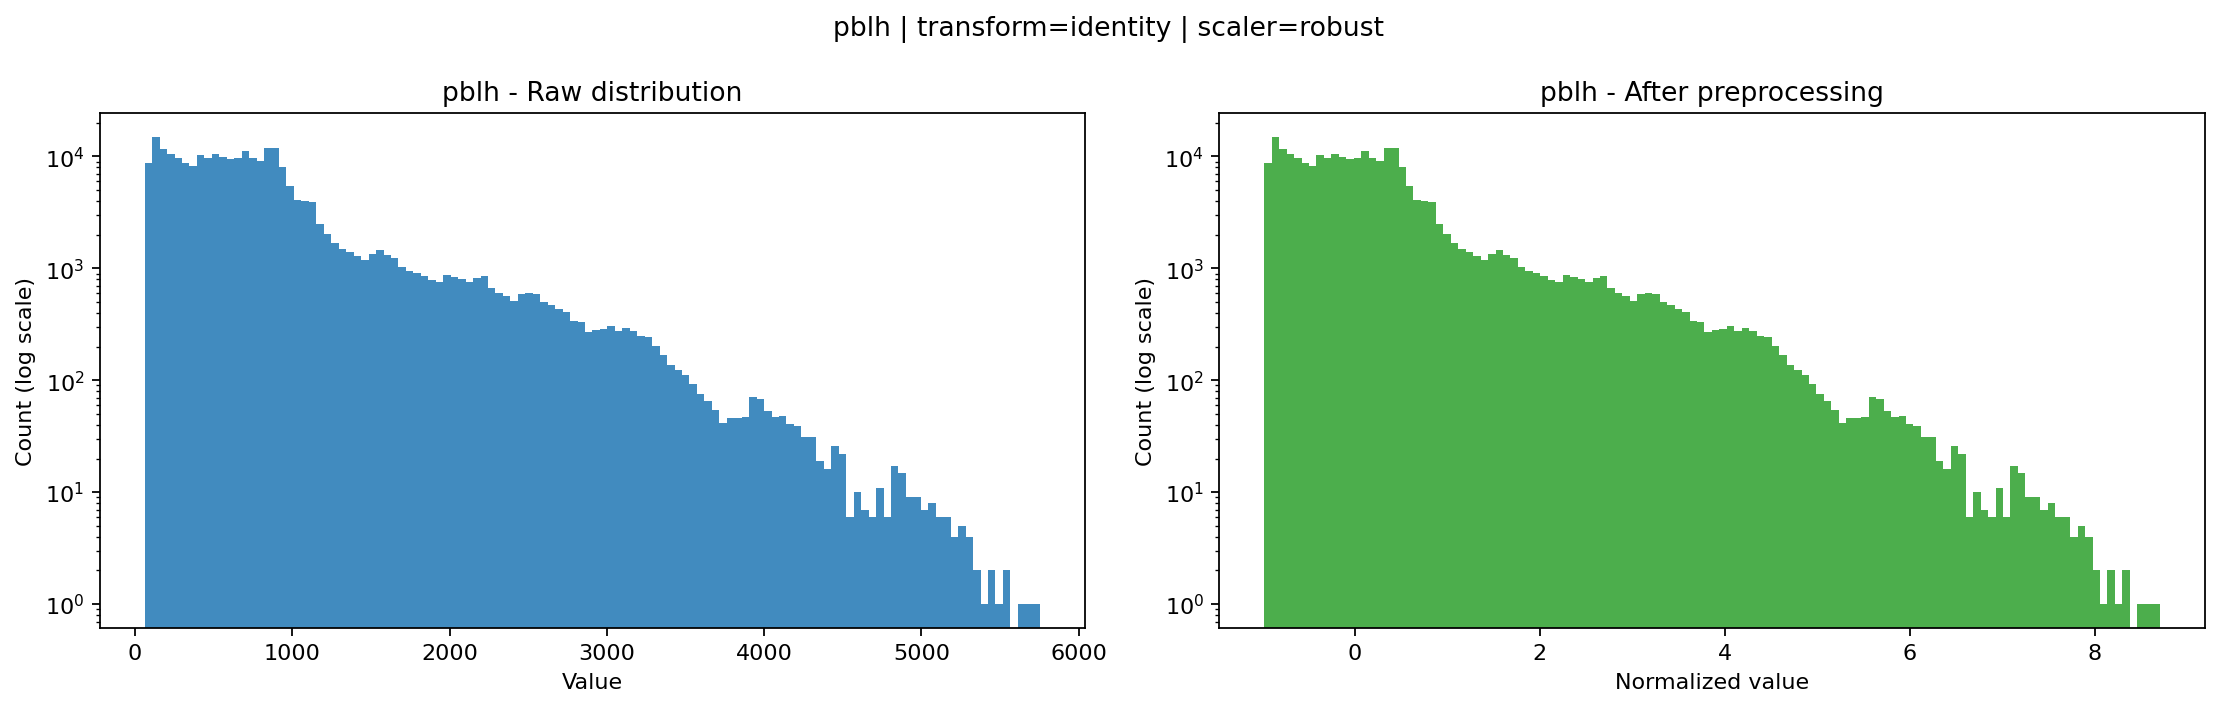

psfc_post_preprocess_distribution.png


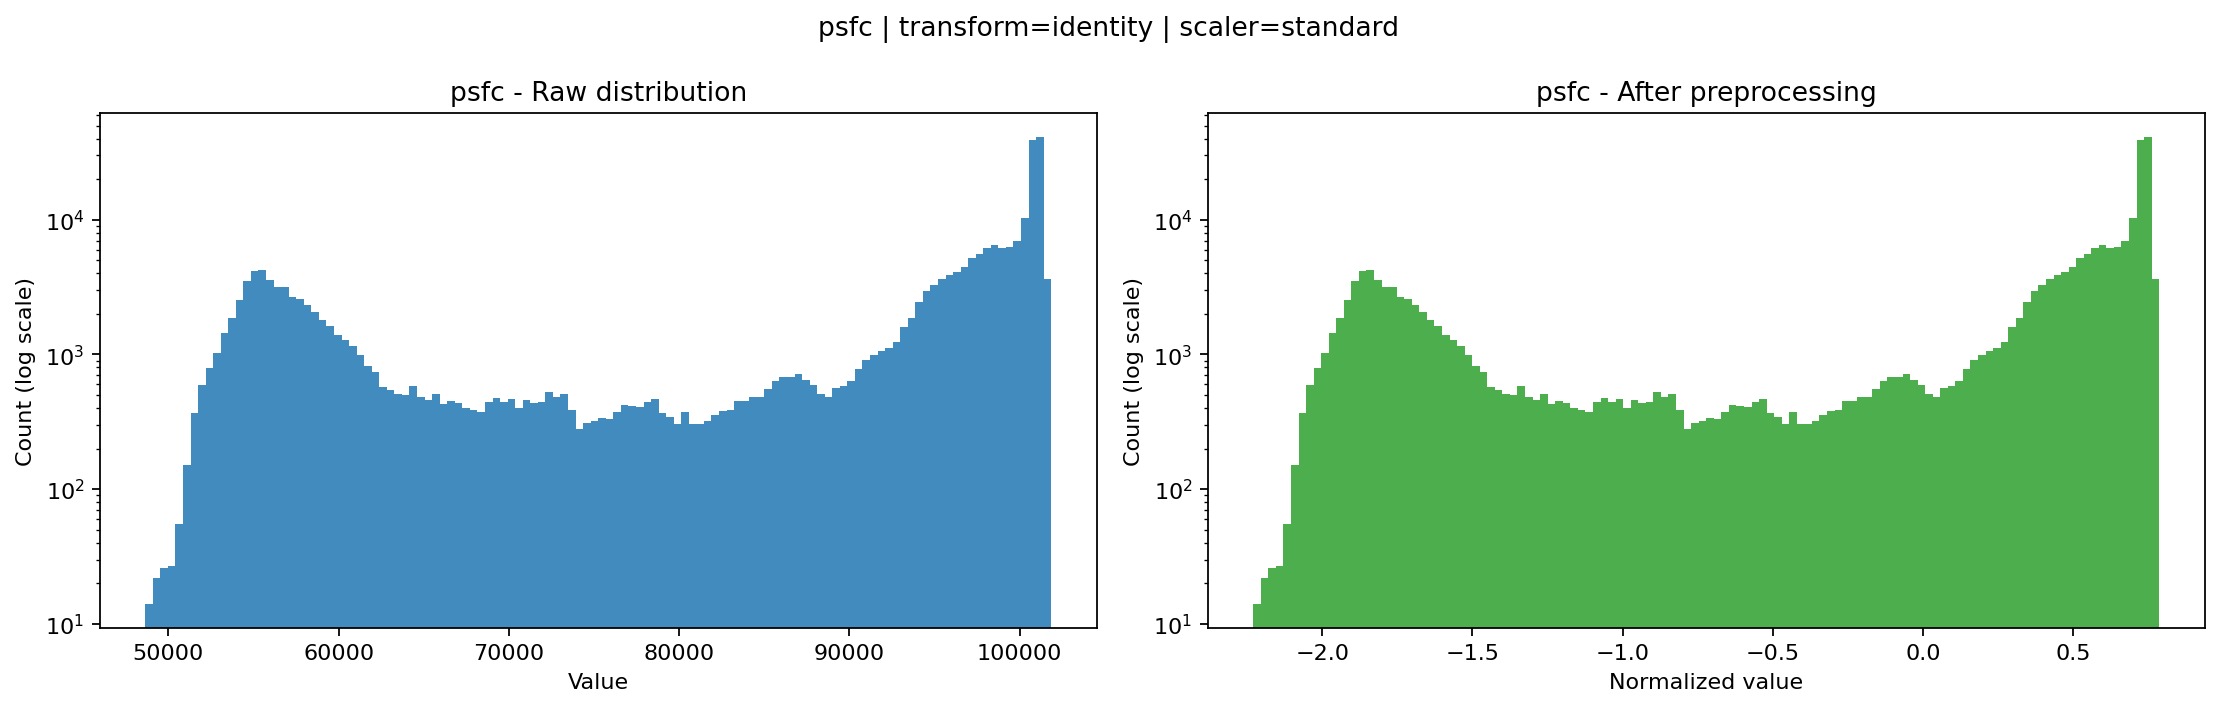

q2_post_preprocess_distribution.png


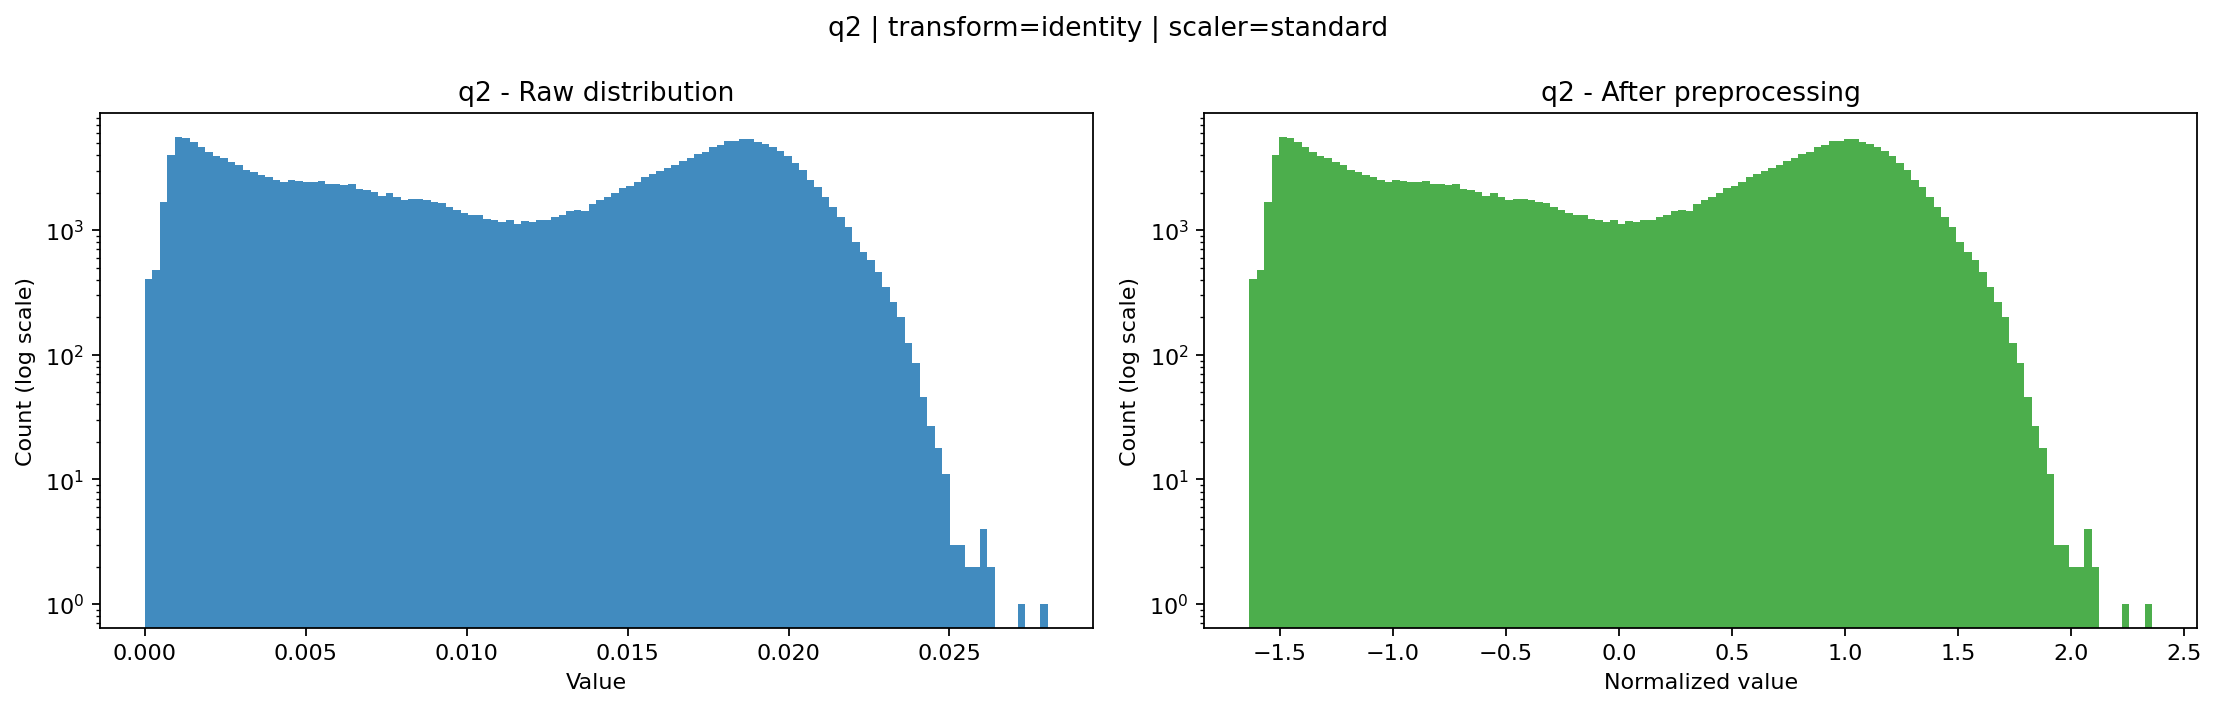

rain_post_preprocess_distribution.png


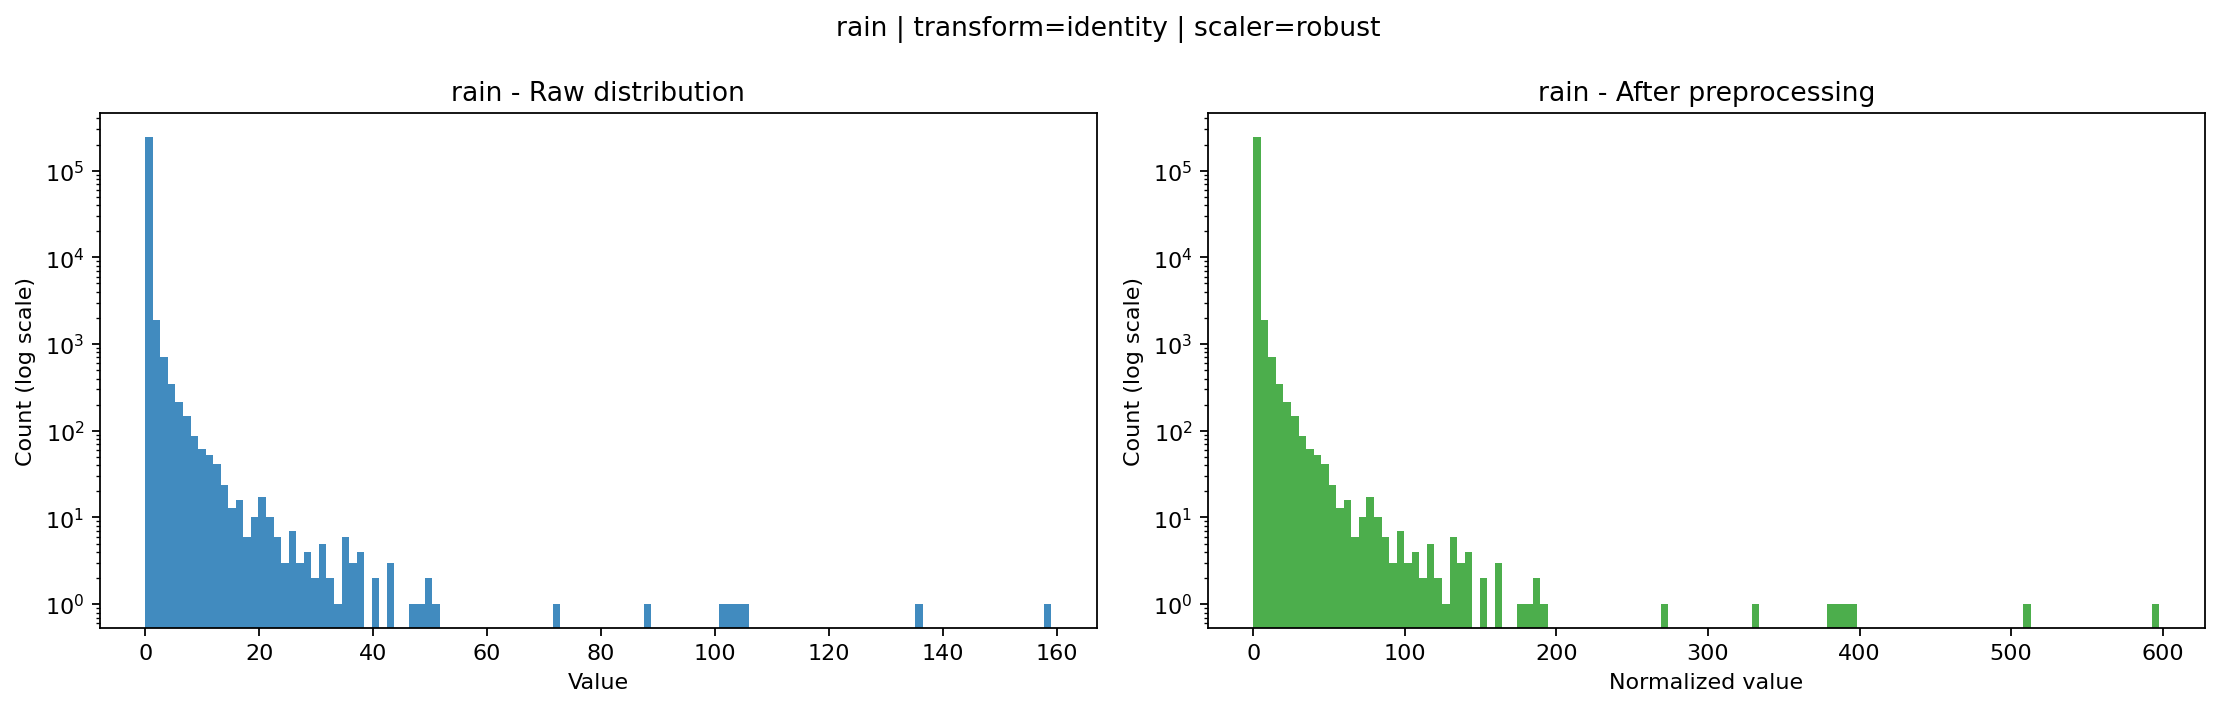

swdown_post_preprocess_distribution.png


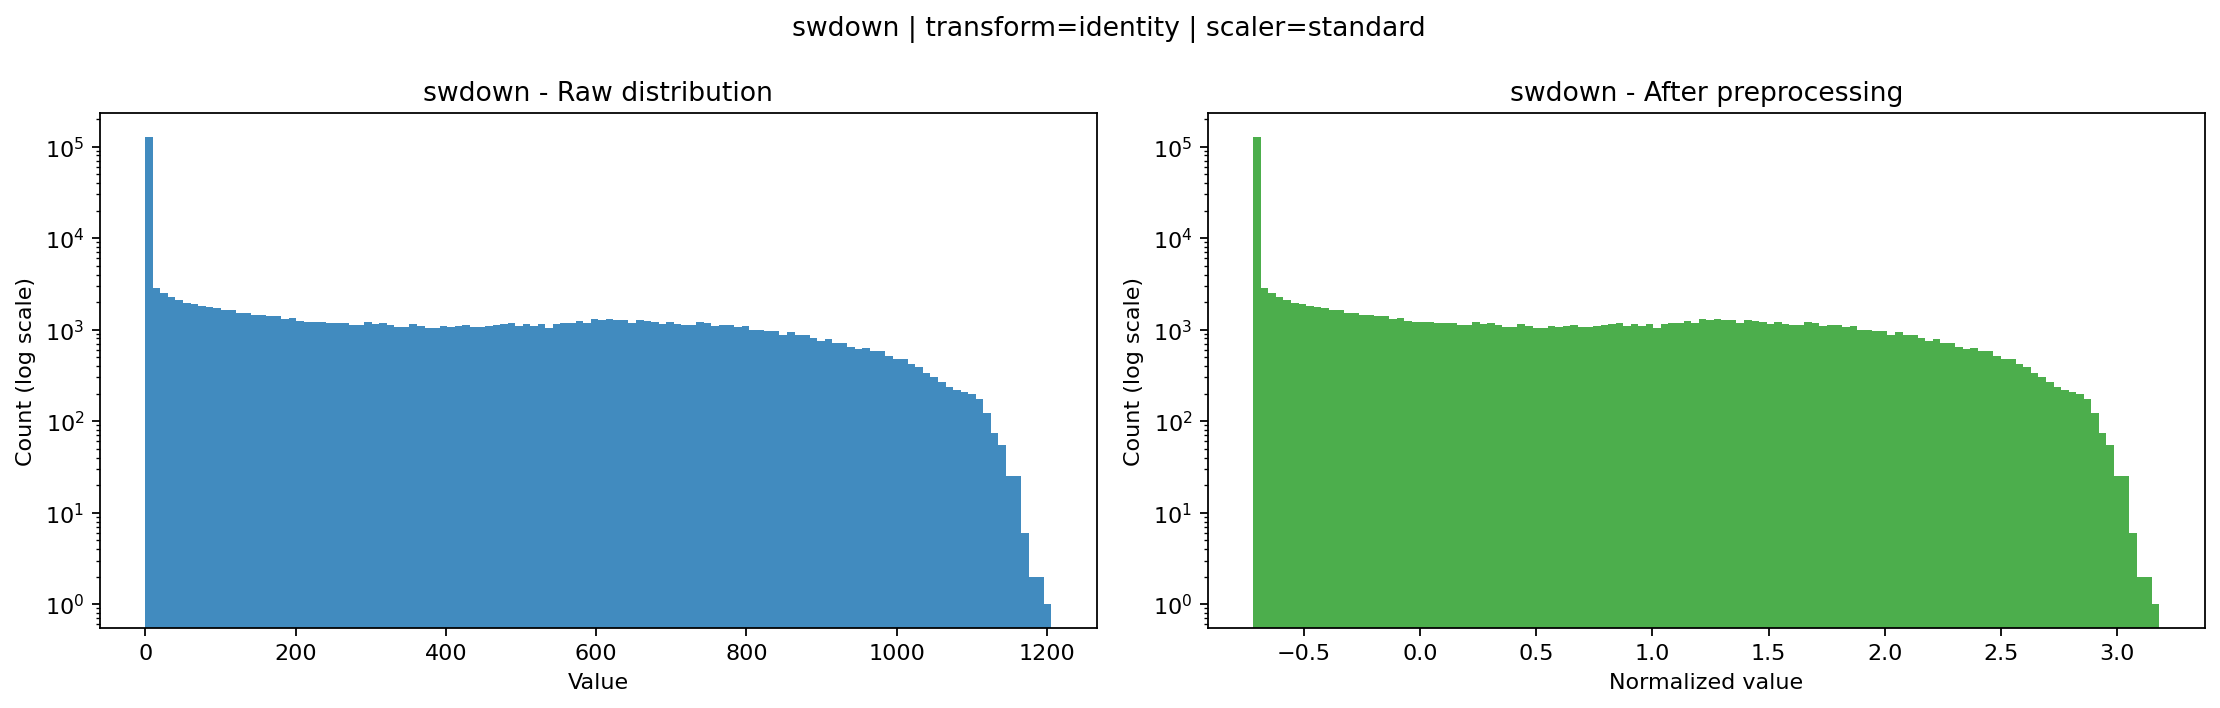

t2_post_preprocess_distribution.png


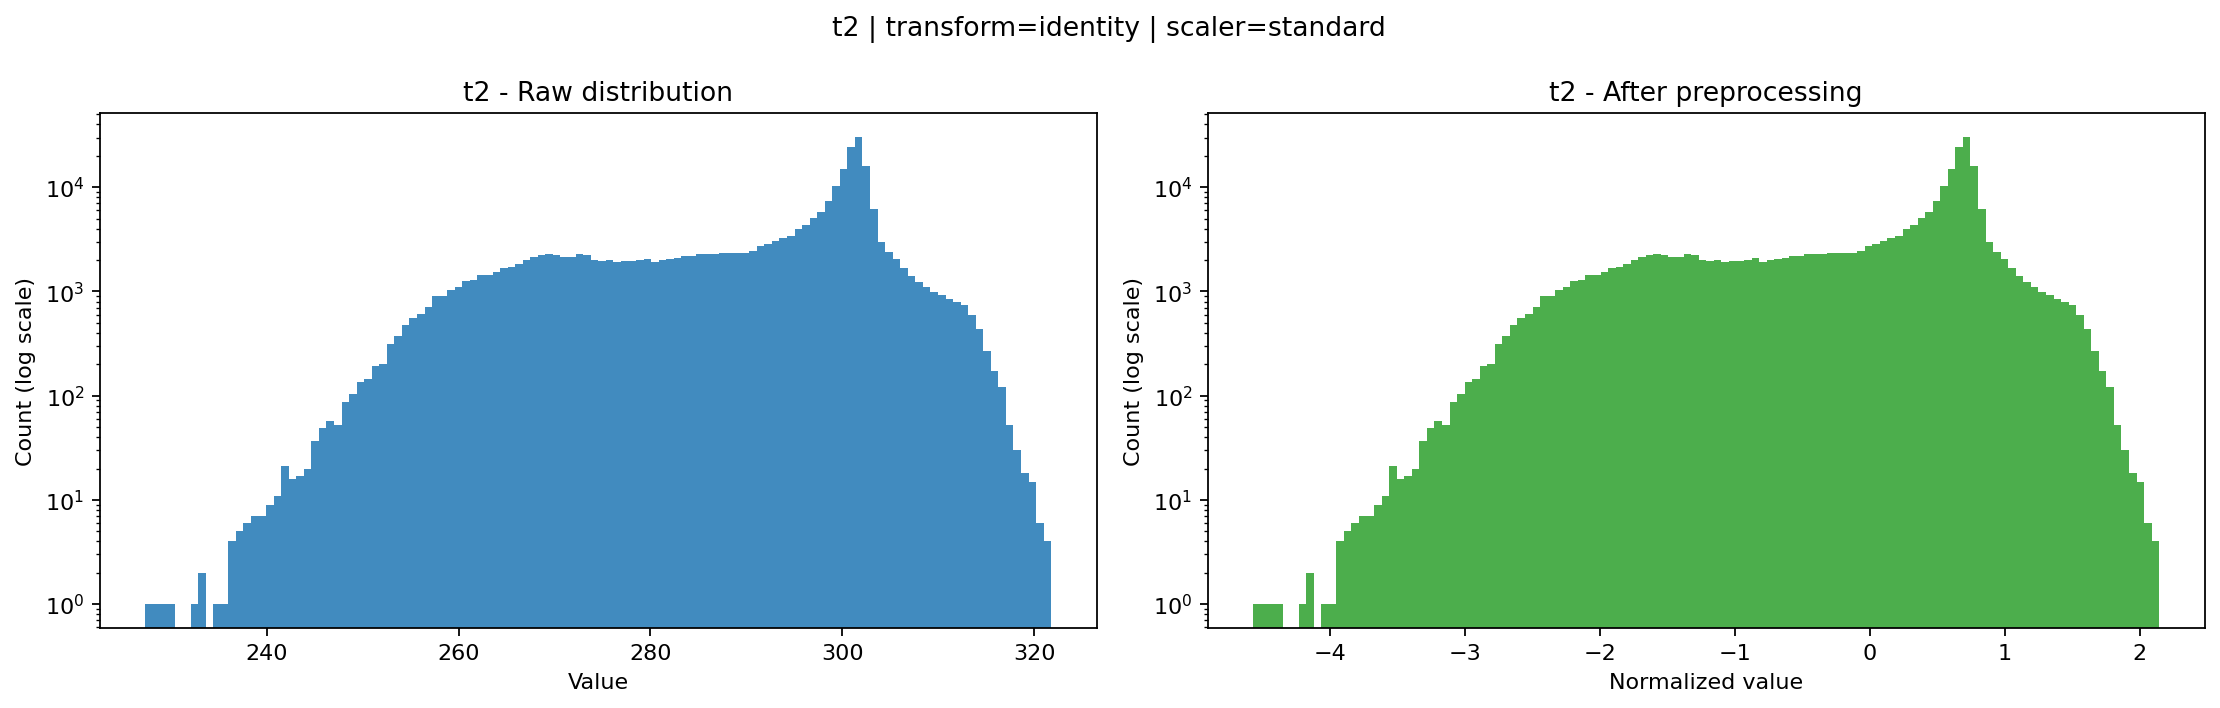

u10_post_preprocess_distribution.png


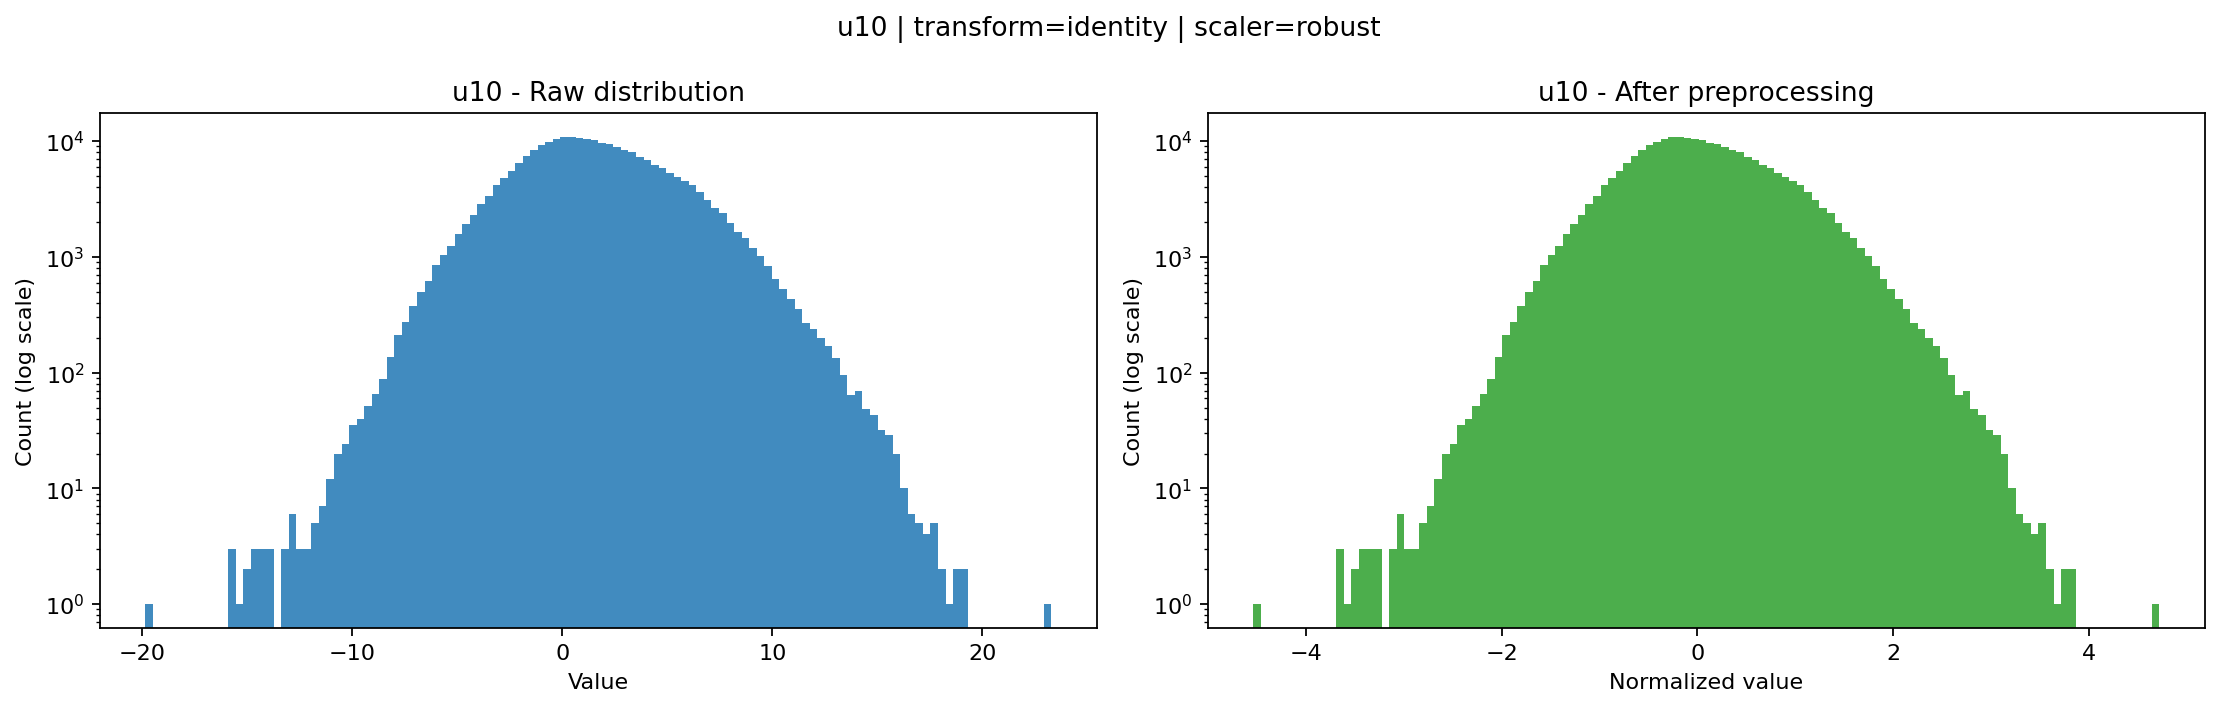

v10_post_preprocess_distribution.png


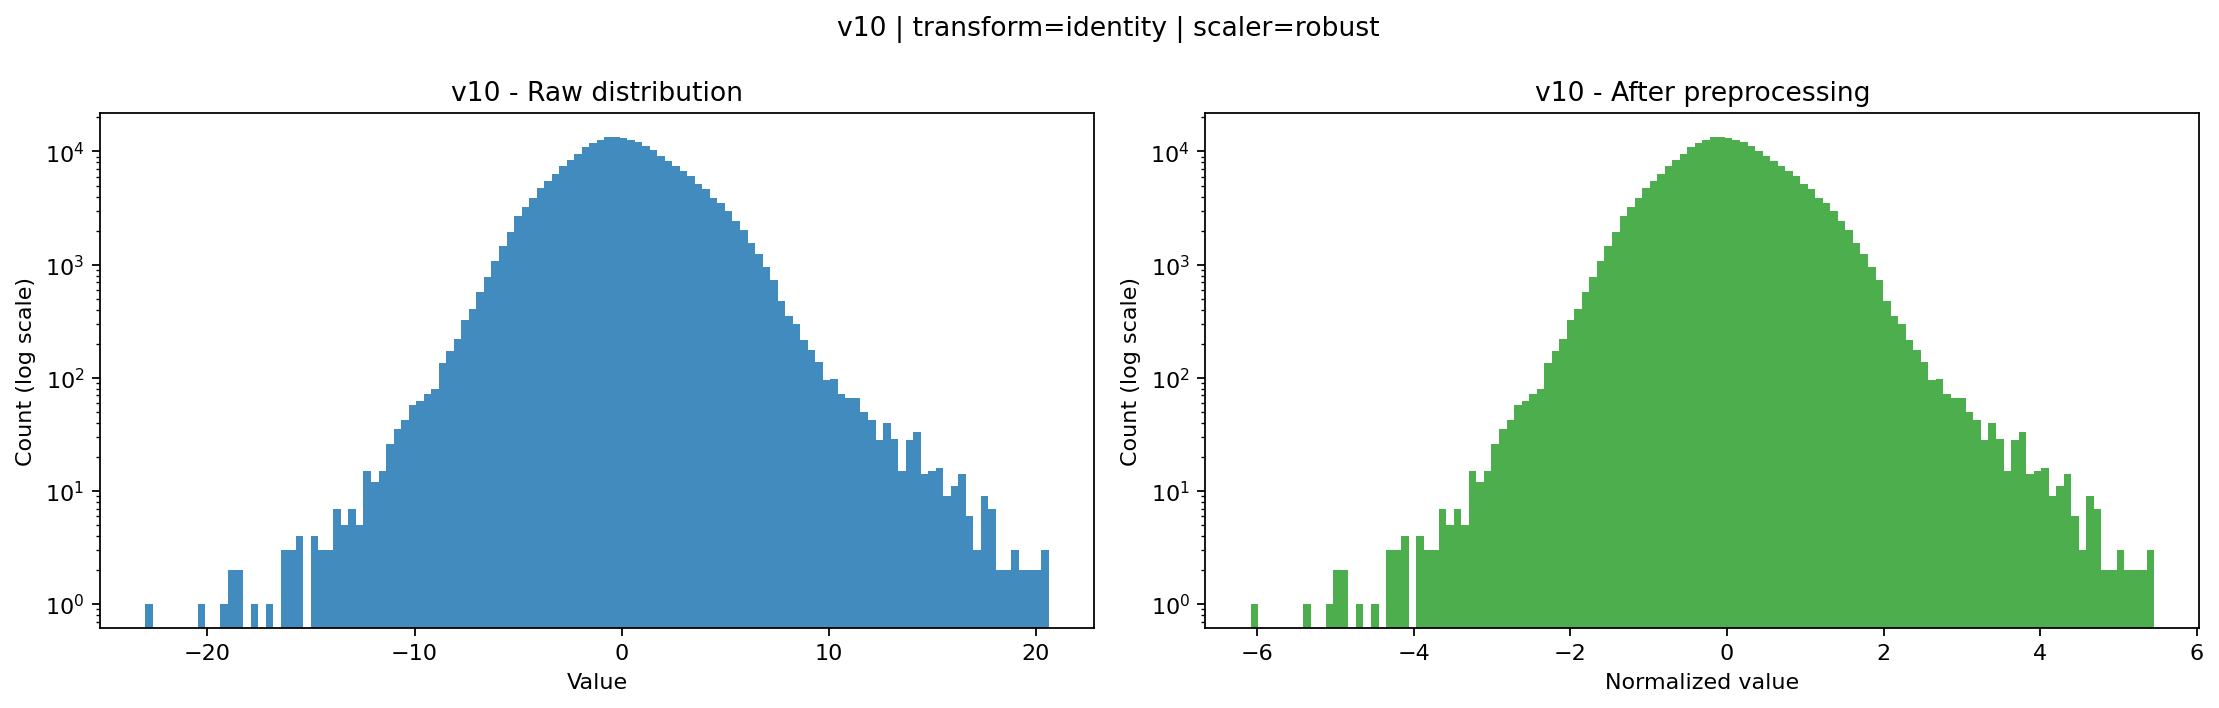

In [3]:
from IPython.display import display, Image

image_paths = sorted(OUT_DIR.glob("*_post_preprocess_distribution.png"))
print(f"Displaying {len(image_paths)} post-preprocessing distribution images")

for img_path in image_paths:
    print(img_path.name)
    display(Image(filename=str(img_path), width=1100))